In [1]:
import numpy as np 
from uncertainties import ufloat
from uncertainties import unumpy as unp
from IPython.display import Latex, HTML, Math, display
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.stats import linregress
import pandas as pd
from scipy import constants as c
from matplotlib.patches import Rectangle
from matplotlib.ticker import MaxNLocator


# zum import von py Dateien
from pathlib import Path
import sys


In [9]:
# Auflösungsvermögen

# 1.1 (aus den Angaben)
la_1 = 576.96 # nm
la_2 = 579.07 # nm
delta_la = la_2-la_1
A = la_1/delta_la
print(f"Das Auflösungsvermögen beträgt {A:.2f}.")

# 1.2
# Herleitung der Berechnung für die Gitterkonstante

# 1.3 
Spalt_b_r = unp.uarray([1.66, 0.96, 0.19],[0.03]) # Blendenbreite nach rechts in mm - unsicherheit weil fadenkreuz bisschen unscharf war
Spalt_b_l = unp.uarray([1.52, 0.84, 0.3],[0.03]) # Blendenbreite nach links in mm
n = np.array([2,3,4]) # Ordnung der Maxima

def gitter(n, B, A):
    return n*B/A

d_l = gitter(n,Spalt_b_l, A)
g_l = np.sum(d_l)/3 # in m
d_r = gitter(n,Spalt_b_r,A)
g_r = np.sum(d_r)/3 # in m
d_mean = (g_l+g_r)/2
print(f"Die Gitterkonstante aus den Werten links vom Hauptmaximum beträgt {g_l} mm.") # 
print(f"Aus der rechten Richtung ergibt sich {g_r} mm.") # 
print(f"Im Mittel errechnet sich dann die Gitterkonstante als {d_mean} mm.") # 

Das Auflösungsvermögen beträgt 273.44.
Die Gitterkonstante aus den Werten links vom Hauptmaximum beträgt 0.00824+/-0.00020 mm.
Aus der rechten Richtung ergibt sich 0.00848+/-0.00020 mm.
Im Mittel errechnet sich dann die Gitterkonstante als 0.00836+/-0.00014 mm.


In [ ]:
# Spektroskopie

# einmal transmission farbglasfilter - wellenlängen der durchlassbereiche bestimmen (ablesen??)
# transmissionspekturm und dann CW und FWHL interferenzfilter (python?? ablesen?) 542 mit 44, 537 und 547 mit 23
# und an beiden seiten interferenzfilter reflexion
# können dann den code ordnen, hier sind va plots

# new Data
Spektrum_k_3 = pd.read_csv("Transmission-k-3.txt", sep=',', decimal='.')


l_3 = Spektrum_k_3["l"].to_numpy() # wellenlänge

I_3 = Spektrum_k_3["I"].to_numpy() # intensität


# Plot with color gradient
plt.figure(figsize=(10, 6))
plt.plot(l_3, I_3, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Spektrum k_3")
plt.grid()
plt.tight_layout()

# new Data
Spektrum_green = pd.read_csv("Transmission-green.txt", sep=',', decimal='.')


l_g = Spektrum_green["l"].to_numpy()

I_g = Spektrum_green["I"].to_numpy()

# Plot with color gradient
plt.figure(figsize=(10, 6))
plt.plot(l_g, I_g, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Spektrum Grün")
plt.grid()
plt.tight_layout()

Spektrum_mir = pd.read_csv("Reflection-spiegel.txt", sep=',', decimal='.')


l_m = Spektrum_mir["l"].to_numpy()

I_m = Spektrum_mir["I"].to_numpy()


# Plot with color gradient
plt.figure(figsize=(10, 6))
plt.plot(l_m, I_m, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Reflection-Spiegelseite")
plt.grid()
plt.tight_layout()

# reflexion
Spektrum_greed = pd.read_csv("Reflection-green.txt", sep=',', decimal='.')


l = Spektrum_greed["l"].to_numpy()

I = Spektrum_greed["I"].to_numpy()

# Plot with color gradient
plt.figure(figsize=(10, 6))
plt.plot(l, I, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Reflektion grüne Seite")
plt.grid()
plt.tight_layout()


# Plot with color gradient
plt.figure(figsize=(10, 6))
plt.plot(l, I, '-', linewidth=1)
plt.plot(l_m, I_m, '-', linewidth=1)
plt.plot(l_g, I_g, '-', linewidth=1)
plt.plot(l_3, I_3, '-', linewidth=1)
plt.xlabel("Wellenlänge in nm")
plt.ylabel("Intensität in %")
plt.title("Maxima-Zeit")
plt.grid()
plt.tight_layout()

Der thermische Ausdehnungskoeffizient beträgt (1.56+/-0.04)e-05 1/K.


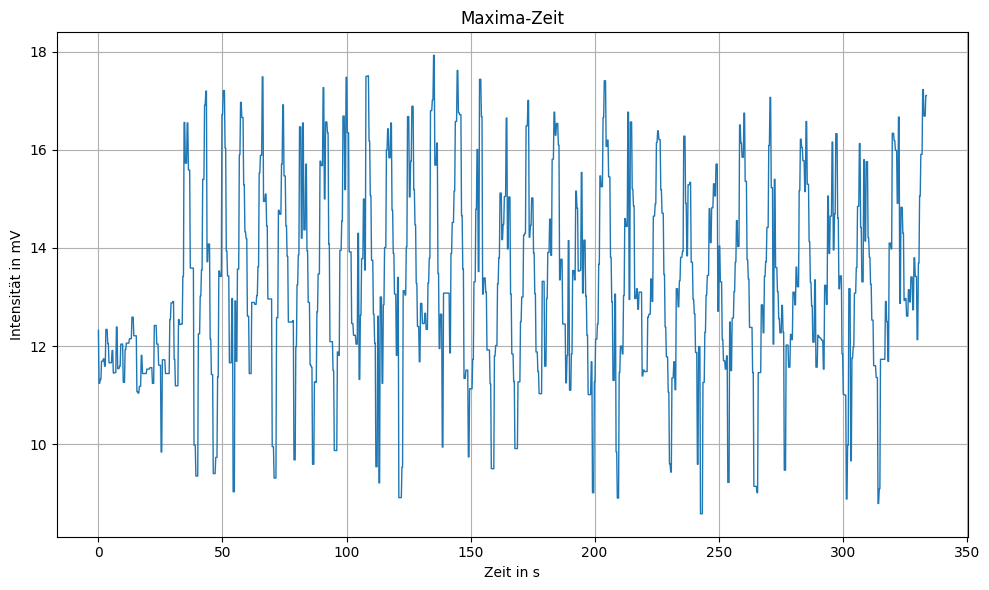

In [19]:
# Michelson

T_s = ufloat(23.5, 0.1)  #°C, unsicherheit ist auflösung thermometer
T_e = ufloat(30.5, 0.1) #°C
lam = ufloat(632.8, 0.01) # wellenlänge in nm
N = ufloat(31*2,1) # abgezählte vielfache von pi-schwingungen
l0 = ufloat(9*(10**7), 0.05*(10**6)) # länge stab in nm
deltaT = T_e - T_s

# new Data
Welle = pd.read_csv("michelson.csv", sep=',', decimal='.')


t = Welle["Time since start of measurement"].to_numpy()

I = Welle["I"].to_numpy()


alpha = (N*lam)/(4*l0*deltaT)
print(f"Der thermische Ausdehnungskoeffizient beträgt {alpha} 1/K.") 


# Plot with color gradient
plt.figure(figsize=(10, 6))
plt.plot(t, I, '-', linewidth=1)
plt.xlabel("Zeit in s")
plt.ylabel("Intensität in mV")
plt.title("Maxima-Zeit")
plt.grid()
plt.tight_layout()